In [2]:
# https://chatgpt.com/share/69f36a6f-8ce8-83e8-ace2-6a5fe7fae3e7

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import random


[[1.5479121 ]
 [0.87775688]
 [1.71719584]
 [1.39473606]
 [0.1883547 ]
 [1.9512447 ]
 [1.5222794 ]
 [1.57212861]
 [0.25622727]
 [0.90077188]
 [0.74159605]
 [1.85352998]
 [1.28773024]
 [1.64552323]
 [0.8868284 ]
 [0.45447744]
 [1.10916957]
 [0.12763451]
 [1.65526234]
 [1.2633288 ]
 [1.51617548]
 [0.70905194]
 [1.94139605]
 [1.78624224]
 [1.55676699]
 [0.38927742]
 [0.93344201]
 [0.08760753]
 [0.30857898]
 [1.36609791]
 [1.48952431]
 [1.93501946]
 [0.65165072]
 [0.74091941]
 [0.93911162]
 [0.37894272]
 [0.25984301]
 [0.95140985]
 [0.4538187 ]
 [1.33962799]
 [0.87430384]
 [1.66535639]
 [1.4005302 ]
 [0.62473328]
 [1.6645196 ]
 [1.60952871]
 [0.77495676]
 [0.57665621]
 [1.36499101]
 [0.27950497]
 [0.3998164 ]
 [0.01472454]
 [1.57384876]
 [1.32970171]
 [1.41033076]
 [1.56145806]
 [0.91783155]
 [1.13748239]
 [0.279594  ]
 [0.22906015]
 [1.33680592]
 [0.94219241]
 [1.13047221]
 [1.52999771]
 [1.26943664]
 [1.1071588 ]
 [1.11841432]
 [0.6079002 ]
 [0.06163567]
 [0.87343478]
 [0.42916935]
 [0.81

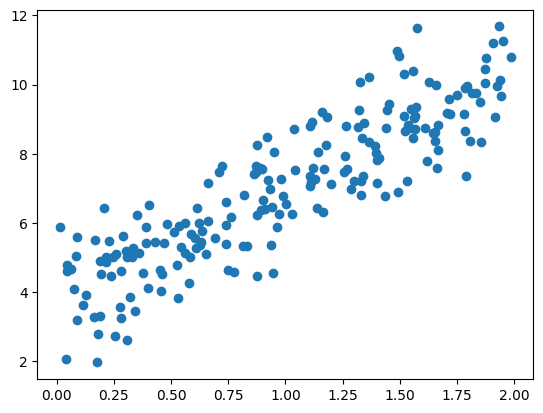

In [4]:
# Recreate the synthetic linear dataset from scratch
# Write the NumPy code that generates X and y, then inspect the scatter plot and verify that the data is approximately linear. This anchors the whole linear regression section.

# Reproducibility
rng = np.random.default_rng(seed=42)

# Number of samples
m = 200

# Feature matrix (uniform in [0, 2])
X = 2 * rng.random((m, 1))

# Target with linear relationship + Gaussian noise
y = 4 + 3 * X + rng.standard_normal((m, 1))
print( X, X.mean())
plt.scatter(X, y)



In [5]:
# Implement the normal equation manually
# Compute X_b, then solve theta_best = (X_b.T @ X_b)^-1 @ X_b.T @ y. Compare the result with the expected intercept and slope. This is the core closed-form example
# to derive the normal equation: basics is required, we know formula for linear graph. we need to know about in ML we do loss function derivative to 0, and matrix form of line is also required for this derivation
# https://claude.ai/chat/106467a9-da45-4c68-a48c-7aaa20d224cf
x_minus_mean = (X - X.mean())
y_minus_mean = (y - y.mean())
# Direct OLS formula (what your code actually does)
m = (y_minus_mean.T @ x_minus_mean) / (x_minus_mean.T @ x_minus_mean)
b = y.mean() - m * X.mean()
print(m, b)

# Actual normal equation via X_b
X_b = np.c_[np.ones((len(X), 1)), X]
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(theta_best)
# theta_best[0] == b, theta_best[1] == m  ← should match
# y_minus_mean = m (x_minus_mean) line eqaution for given points, since linear regression line goes through mean
# dot producting x with both y_minus_mean and x_minus_mean 
# y_minus_mean.X = x_minus_mean.X.M




[[3.32960458]] [[3.69084138]]
[[3.69084138]
 [3.32960458]]


In [6]:
# Repeat the same fit with Scikit-Learn’s LinearRegression
# Fit the model, print intercept_, coef_, and predictions. Then confirm that Scikit-Learn gives the same output as the manual solution.

model = LinearRegression()
model.fit(X, y)

print("intercept:", model.intercept_[0])
print("slope:", model.coef_[0][0])

intercept: 3.6908413834642553
slope: 3.3296045821528386


In [7]:
# Compute the pseudoinverse version
# Use np.linalg.pinv(X_b) @ y and compare it with np.linalg.lstsq. This helps you remember why SVD-based solving is more robust than directly inverting matrices

np.linalg.pinv(X_b) @ y

In [ ]:
# To understand regularization, we first need to understand why it exists.
# Regularization is used to control overfitting in machine learning models.

# A model can fail in two main ways:
# 1. Underfitting  -> model is too simple to learn the real pattern
# 2. Overfitting   -> model learns noise along with the real pattern

# These behaviors are explained using:
# - Bias
# - Variance

# bias and variance are concepts and not indicators. we use proxy for those to see bias variance tradeoff graph

# ------------------------------------------------------------
# BIAS
# ------------------------------------------------------------
# Bias measures how far the model's predictions are from the true relationship.
# Bias proxy    → train error  (high train error = model can't learn the pattern = high bias)

# High Bias:
# - Model makes strong simplifying assumptions
# - Cannot capture the actual pattern
# - Training error is high
# - Test error is also high
# - Leads to UNDERFITTING
#
# Example:
# Trying to fit a straight line to highly curved data.

# ------------------------------------------------------------
# VARIANCE
# ------------------------------------------------------------
# Variance measures how sensitive the model is to small changes in training data.
# Variance proxy → gap between val and train error  (large gap = model memorized training data = high variance)

#
# High Variance:
# - Model learns training data too closely
# - Captures noise/random fluctuations
# - Training error becomes very low
# - Test error becomes high
# - Leads to OVERFITTING
#
# Example:
# Using a very high-degree polynomial that bends through every point.

# ------------------------------------------------------------
# BIAS-VARIANCE TRADEOFF
# ------------------------------------------------------------
# As model complexity increases:
#
# - Bias decreases
#   because the model becomes flexible enough to learn more patterns.
#
# - Variance increases
#   because the model becomes too sensitive to training data.
#
# Goal:
# Find the balance where test error is minimum.

# ------------------------------------------------------------
# GRAPH OF BIAS AND VARIANCE
# ------------------------------------------------------------
#
# x-axis  -> Model Complexity
# y-axis  -> Error
#
# Curves:
#
# 1. Bias^2 curve:
#    - Starts high
#    - Decreases as complexity increases
#
# 2. Variance curve:
#    - Starts low
#    - Increases as complexity increases
#
# 3. Test Error curve:
#    - U-shaped
#    - Initially decreases
#    - Then increases due to overfitting
#
# Left side  -> Underfitting (High Bias)
# Right side -> Overfitting (High Variance)

# ------------------------------------------------------------
# WHAT IS "MODEL COMPLEXITY"?
# ------------------------------------------------------------
# Model complexity means how flexible/powerful the model is.
# More complexity means the model can fit more complicated patterns.

# ------------------------------------------------------------
# MODEL COMPLEXITY IN LINEAR REGRESSION
# ------------------------------------------------------------
# In Linear Regression, complexity can increase by:
#
# 1. Increasing number of features
#    Example:
#    y = b0 + b1*x1 + b2*x2 + b3*x3 + ...
#
# 2. Using polynomial features
#    Example:
#
#    Degree 1:
#    y = b0 + b1*x
#
#    Degree 2:
#    y = b0 + b1*x + b2*x^2
#
#    Degree 10:
#    y = b0 + b1*x + b2*x^2 + ... + b10*x^10
#
# Higher polynomial degree => higher model complexity

# ------------------------------------------------------------
# MODEL COMPLEXITY IN OTHER MODELS
# ------------------------------------------------------------
#
# Decision Tree:
# - Depth of tree
# - Number of leaf nodes
#
# Neural Network:
# - Number of layers
# - Number of neurons
#
# KNN:
# - Smaller K => more complex model
#
# SVM:
# - More flexible kernel => higher complexity


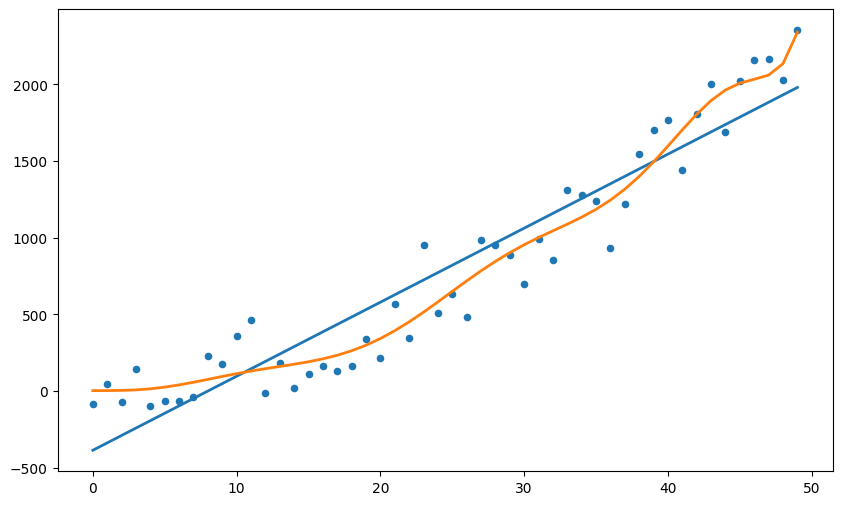

In [ ]:
# practical of bias variance tradeoff showing underfitting overfitting and bias variance

# underfitting

# Data
data_count = 50
y_square = np.array([(i)**2 for i in range(data_count)]).reshape(data_count, 1) + rng.standard_normal((data_count, 1)) * 150  # add Gaussian noise
X = np.array([i for i in range(data_count)]).reshape(data_count, 1)

# Original data
plt.figure(figsize=(10,6))
plt.scatter(X, y_square, label="Actual Data", s=20)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y_square)

y_pred_linear = linear_model.predict(X)
plt.plot(X, y_pred_linear, label="Linear Regression", linewidth=2)


# over fitting
# polynomial regression
# Example with one feature:

# Example with 1 features like above:
# x = [C, x, x2] = [1, 2, 4]
# model equation is: y = aC + bx, cx2, we train the model to find a, b, c


# Example with two features:
# [x1​, x2​]→[1, x1​, x2​, x12​, x22​, x1​x2​] 
# x12 is x1*x2
# model equation is y = a(1)+bx1+cx2+dx12+ex22+fx1x2

# Polynomial Regression

# Create polynomial features and fit linear regression on the expanded matrix
# Use PolynomialFeatures(degree=2) first, then try degree 10. Compare the resulting curves so you remember how a linear model can fit nonlinear data after feature expansion.
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_square)

y_pred_poly = poly_model.predict(X_poly)

# Plot polynomial predictions
plt.plot(X, y_pred_poly, label="Polynomial Regression (degree=2)", linewidth=2)





degree= 1  train_MSE= 52854.3  val_MSE= 74882.9
degree= 2  train_MSE= 27967.5  val_MSE= 26862.2
degree= 3  train_MSE= 27919.0  val_MSE= 26373.1
degree= 4  train_MSE= 27887.6  val_MSE= 27703.6
degree= 5  train_MSE= 26970.4  val_MSE= 32621.8
degree=10  train_MSE= 24192.7  val_MSE= 45092.2


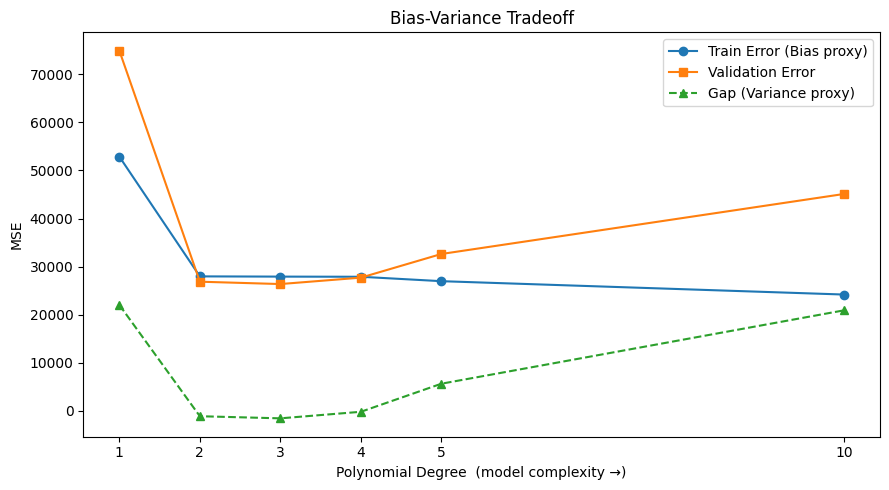

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# IMPORTANT

# HOW TO DIAGNOSE BIAS AND VARIANCE FROM TRAIN/VAL ERROR:
#
# Bias proxy    → train error  (high train error = model can't learn the pattern = high bias)
# Variance proxy → gap between val and train error  (large gap = model memorized training data = high variance)
# Val error alone → total error on unseen data (what matters in production), NOT variance by itself
#
# Ideal: both train and val errors are low AND close to each other
# Underfit (high bias):   train high, val high,  small gap  → degree 1 here
# Sweet spot:             train low,  val low,   small gap  → degree 3 here
# Overfit (high variance): train low, val high,  large gap  → degree 10 here

degrees = [1, 2, 3, 4, 5, 10]

X_train, X_val, y_train, y_val = train_test_split(X, y_square, test_size=0.2, random_state=42)

train_errors = []
val_errors   = []

for d in degrees:
    # Make a pipeline for polynomial regression

    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    val_mse   = mean_squared_error(y_val,   model.predict(X_val))

    train_errors.append(train_mse)
    val_errors.append(val_mse)
    print(f"degree={d:2d}  train_MSE={train_mse:8.1f}  val_MSE={val_mse:8.1f}")

gap = [v - t for v, t in zip(val_errors, train_errors)]

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_errors, marker='o', label='Train Error (Bias proxy)')
plt.plot(degrees, val_errors,   marker='s', label='Validation Error')
plt.plot(degrees, gap,          marker='^', label='Gap (Variance proxy)', linestyle='--')
plt.xlabel('Polynomial Degree  (model complexity →)')
plt.ylabel('MSE')
plt.title('Bias-Variance Tradeoff')
plt.xticks(degrees)
plt.legend()
plt.tight_layout()
plt.show()

# we select the model whose validation error is minimum

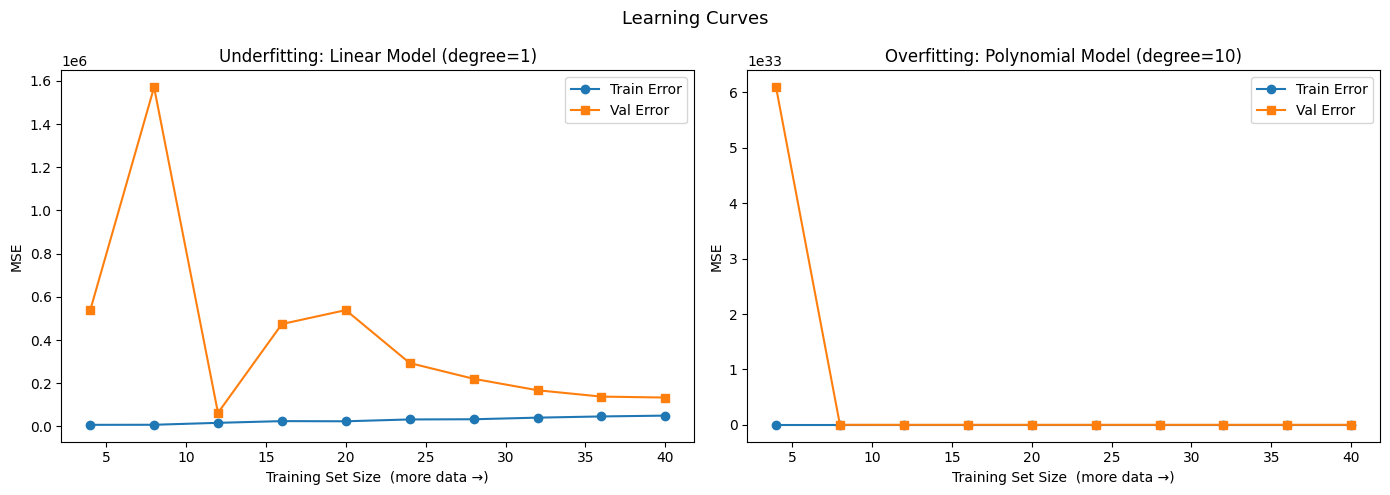

In [44]:
from sklearn.model_selection import learning_curve

# Learning curve: x-axis = training set size (NOT model complexity)
# Shows how train and val error change as you feed more data to the model
#
# Underfitting pattern: both errors HIGH and converge → more data won't help
# Overfitting pattern:  train LOW, val HIGH, large gap → more data will help close the gap

def plot_learning_curve(model, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y_square,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='neg_mean_squared_error'
    )
    train_mse = -train_scores.mean(axis=1)
    val_mse   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mse, marker='o', label='Train Error')
    ax.plot(train_sizes, val_mse,   marker='s', label='Val Error')
    ax.set_title(title)
    ax.set_xlabel('Training Set Size  (more data →)')
    ax.set_ylabel('MSE')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Underfitting: plain linear model on quadratic data
linear_model = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
plot_learning_curve(linear_model, 'Underfitting: Linear Model (degree=1)', axes[0])

# Overfitting: high-degree polynomial on small data
poly_model = make_pipeline(PolynomialFeatures(degree=10), LinearRegression())
plot_learning_curve(poly_model, 'Overfitting: Polynomial Model (degree=10)', axes[1])

plt.suptitle('Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

# KEY DIFFERENCE FROM BIAS-VARIANCE TRADEOFF PLOT:
# Bias-Variance plot  → x-axis is model complexity  (which degree is best?)
# Learning Curve      → x-axis is training set size  (does more data help?)

In [ ]:
# How regularization is able to add bias to the model params in a way that it doesn't overfit the training data and get generalized for testing data/all other kinds of data 

# make the model prefer simpler parameter configurations unless the data strongly justifies complexity
# or
# make model use less weight unless its absolutely necessary to have high weight

# IMP
# to achieve this, one way is to change the loss function by adding an extra penalty term proportional to the magnitude of the weights, so large weights increase the loss unless they are truly useful

In [1]:
# ridge regression uses loss function as 
# L = MSE + lamdba*m**2 where m is weight. if weight becomes high, loss will become high and we want to minimize the loss

# how to choose lamdba?
# A small (\lambda) allows the model to fit more flexibly (risking overfitting), while a large (\lambda) forces weights to stay small (risking underfitting).
# In practice, multiple values of (\lambda) are tested using techniques like cross-validation, and the one giving the best performance on unseen validation data is selected.


# Important but I don't understand this completely
# difference between ridge and lasso regression.
# Ridge: “Use all the information carefully.” 
# Lasso: “Find the few variables that really matter.”
# one way to understand this would be to first see what the weights looks like after both type of regression is done